# Industrial Computer Vision

In [1]:
from matplotlib import pyplot as plt
from numpy import array
from PIL import Image

from tensorflow.keras.utils import image_dataset_from_directory

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D # Zum Schärfen unseres Bildes
from tensorflow.keras.layers import MaxPool2D # Zum "Einkochen unserer Bilder"
from tensorflow.keras.layers import Dense, Input, Flatten

from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import RandomBrightness, RandomFlip, RandomZoom

from tensorflow.random import set_seed

set_seed(123)

## Look into images

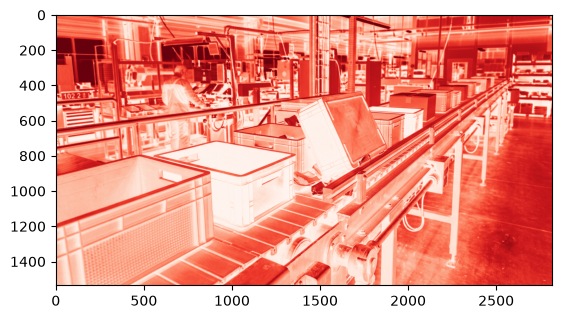

In [2]:
plt.imshow(plt.imread("../data/jammed/image_02.jpeg")[:,:,0], cmap="Reds")

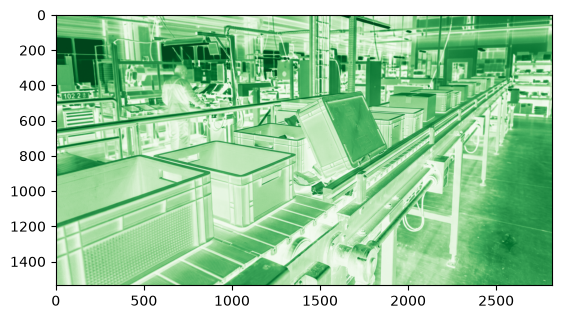

In [3]:
plt.imshow(plt.imread("../data/jammed/image_02.jpeg")[:,:,1], cmap="Greens")

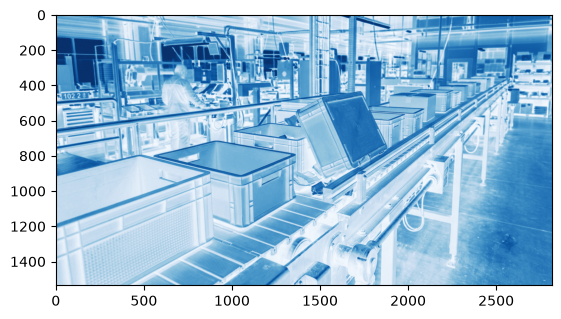

In [4]:
plt.imshow(plt.imread("../data/jammed/image_02.jpeg")[:,:,2], cmap="Blues")

## Load Data

In [5]:
training_data = image_dataset_from_directory(
    "../data",
    image_size=(224, 224),
    batch_size=3,
    seed=123
)

Found 12 files belonging to 3 classes.


In [6]:
training_data.class_names

['empty', 'free', 'jammed']

In [30]:
for images, labels in training_data.take(10):
    print(labels)
    print(images.shape)

tf.Tensor([1 2 0], shape=(3,), dtype=int32)
(3, 224, 224, 3)
tf.Tensor([2 1 1], shape=(3,), dtype=int32)
(3, 224, 224, 3)
tf.Tensor([2 1 2], shape=(3,), dtype=int32)
(3, 224, 224, 3)
tf.Tensor([1 2 1], shape=(3,), dtype=int32)
(3, 224, 224, 3)


## Create Model

In [31]:
model = Sequential()
model.add(Input(shape=(224, 224, 3)))

# Image Augmentation
#model.add(RandomFlip())
#model.add(RandomZoom(0.2))
#model.add(RandomBrightness(-0.2))

# Bildverarbeitung
model.add(Conv2D(24, kernel_size=3, activation="relu"))
model.add(MaxPool2D(pool_size=2))
model.add(Conv2D(12, kernel_size=3, activation="relu"))
model.add(MaxPool2D(pool_size=2))
model.add(Flatten())

# Klassifizierung
model.add(Dense(64, activation="relu"))
model.add(Dropout(0.25))
model.add(Dense(3, activation="softmax"))

In [32]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 24)   │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 24)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 12)   │         2,604 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 34992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     2,239,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,243,023 (8.56 MB)

 Trainable params: 2,243,023 (8.56 MB)

 Non-trainable params: 0 (0.00 B)

## Model Nutzen

In [33]:
img = plt.imread("../data/empty/image_06.jpeg")

img_pil = Image.fromarray(img)
img_arr = array(img_pil.resize((224, 224)))/256
img_arr = img_arr.reshape(1, 224, 224, 3)

model.predict(img_arr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


array([[0.35417536, 0.3172428 , 0.3285818 ]], dtype=float32)

## Model Training

In [34]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy"
)

In [35]:
log = model.fit(training_data, epochs=15, verbose=1)

Epoch 1/15


/Users/michaelkohlegger/Documents/GitHub/industrial_computing_dibse_26/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 430.6898
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 189.5432
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 6.8475
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.8803
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.0646
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4622
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6245
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4090
Epoch 9/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3924
Epoch 10/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3427
Epoch 11/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2323
Epoch 12/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2120
Epoch 13/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1875
Epoch 14/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1452
Epoch 15/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0708


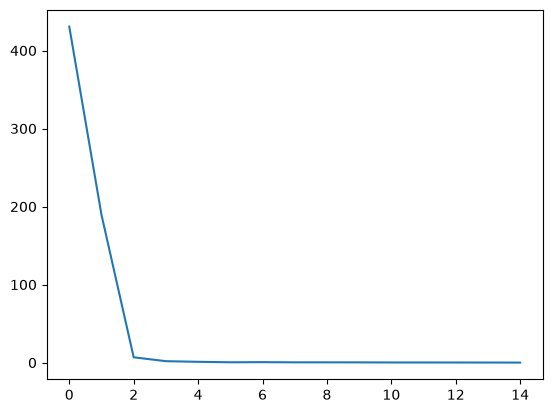

In [36]:
plt.plot(log.history["loss"])

## Model ausprobieren

In [37]:
img = plt.imread("../data/free/image_01.jpeg")

img_pil = Image.fromarray(img)
img_arr = array(img_pil.resize((224, 224)))
img_arr = img_arr.reshape(1, 224, 224, 3)

model.predict(img_arr).argmax()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


np.int64(1)

In [38]:
training_data.class_names

['empty', 'free', 'jammed']